In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar dataset limpio
df_data = pd.read_csv("../data/develop_dataset_2025_limpio.csv", index_col=0)



## Análisis Bivariante

In [2]:
# Variables principales del análisis bivariante

salary_col = "ConvertedCompYearly"

numeric_cols_biv = df_data.select_dtypes(include="number").columns
categorical_cols_biv = df_data.select_dtypes(include=["object", "string", "category"]).columns

print("Variables numéricas:")
print(numeric_cols_biv)

print("\nVariables categóricas:")
print(categorical_cols_biv)

Variables numéricas:
Index(['ConvertedCompYearly', 'WorkExp', 'YearsCode', 'JobSat'], dtype='str')

Variables categóricas:
Index(['Age', 'EdLevel', 'Employment', 'AISelect', 'Industry', 'Country',
       'DevType'],
      dtype='str')


H1

In [3]:
# H1: Preparar orden de la variable Age

age_order = [
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old", 
    "65 years or older",
    "Prefer not to say"
]

df_data["Age"] = pd.Categorical(df_data["Age"], categories=age_order, ordered=True)

In [4]:
# H1: Estadísticas salariales por rango de edad

salario_edad = df_data.groupby("Age", observed=True)[salary_col].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

salario_edad

,count,mean,median,min,max
Age,,,,,
18-24 years old,166,32848.33,21149.5,1.0,278435.0
25-34 years old,686,94113.71,69872.0,1.0,4706124.0
35-44 years old,513,118713.93,90000.0,1.0,2346000.0
45-54 years old,249,125507.11,108913.0,17.0,725000.0
55-64 years old,100,117432.18,103207.5,10.0,390561.0
65 years or older,26,134961.77,130210.0,20000.0,350000.0
Prefer not to say,1,162523.00,162523.0,162523.0,162523.0


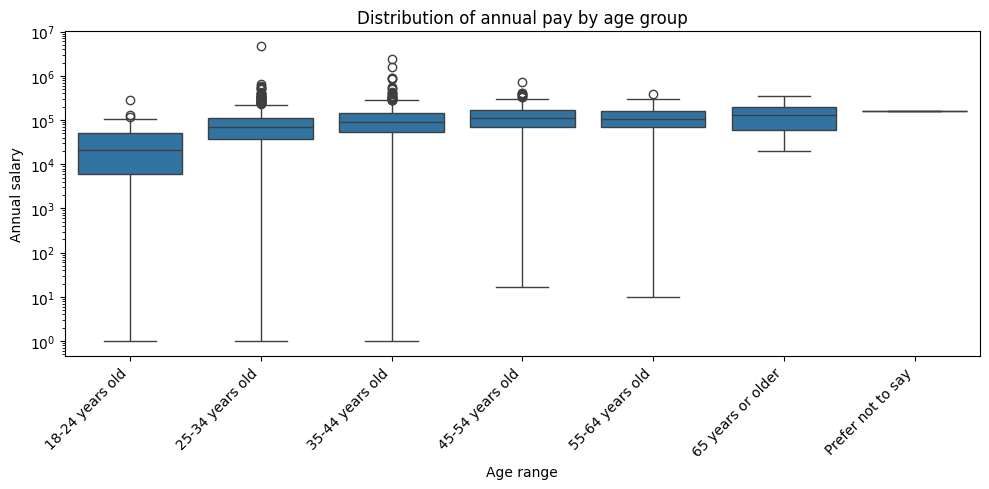

In [5]:
# H1: Boxplot salario por edad

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_data, x="Age", y=salary_col, order=age_order)
plt.title("Distribution of annual pay by age group")
plt.xlabel("Age range")
plt.ylabel("Annual salary")
plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

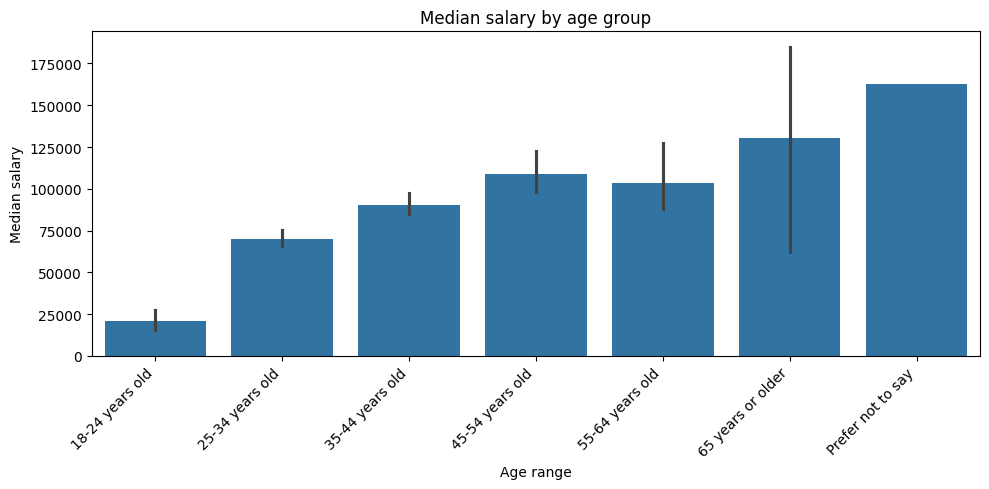

In [6]:
# H1: Mediana salarial por edad

plt.figure(figsize=(10, 5))
sns.barplot(data=df_data, x="Age", y=salary_col, order=age_order, estimator="median")
plt.title("Median salary by age group")
plt.xlabel("Age range")
plt.ylabel("Median salary")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Conclusión H1

Los resultados muestran una tendencia general positiva entre la edad y el salario anual. La mediana salarial aumenta desde los 20.883 en el grupo de 18-24 años hasta los 108.913 en el grupo de 45-54 años. El grupo de 65 años o más presenta la mediana más alta, con 130.210, aunque debe interpretarse con cautela debido a su bajo número de registros.

No obstante, la relación no es completamente lineal, ya que el grupo de 55-64 años presenta una mediana ligeramente inferior a la del grupo de 45-54 años. Además, existen valores atípicos salariales importantes, especialmente en los grupos de 25-34 y 35-44 años, por lo que la mediana resulta más representativa que la media.

En conjunto, la hipótesis H1 se acepta parcialmente: existe una relación positiva general entre edad y salario, aunque con excepciones y diferencias de tamaño muestral entre grupos.

H2.1.

In [7]:
# H2: Tabla cruzada entre nivel educativo y situación laboral

tabla_ed_employment = pd.crosstab(
    df_data["EdLevel"],
    df_data["Employment"],
    normalize="index"
) * 100

tabla_ed_employment.round(2)

Employment,Employed,Freelancer,I prefer not to say,Not employed,Retired,Student
EdLevel,,,,,,
Associate,72.41,20.69,0.00,6.90,0.00,0.00
Bachelor,85.35,10.49,0.00,1.63,0.18,2.35
Master,87.55,8.95,0.00,1.96,0.56,0.98
Other (please specify):,53.85,23.08,0.00,7.69,7.69,7.69
Primary,44.44,33.33,0.00,11.11,11.11,0.00
Professional,85.09,12.00,0.00,1.45,1.45,0.00
Secondary,67.39,19.57,4.35,2.17,0.00,6.52
Some College,72.28,16.83,0.00,4.95,0.99,4.95


In [8]:
# H2: Porcentaje de empleados por nivel educativo

empleados_por_ed = df_data.assign(
    is_employed=df_data["Employment"].eq("Employed")
).groupby("EdLevel")["is_employed"].agg(["count", "mean"])

empleados_por_ed["percentage_of_employees"] = empleados_por_ed["mean"] * 100

empleados_por_ed.sort_values("percentage_of_employees", ascending=False).round(2)

,count,mean,percentage_of_employees
EdLevel,,,
Master,715,0.88,87.55
Bachelor,553,0.85,85.35
Professional,275,0.85,85.09
Associate,29,0.72,72.41
Some College,101,0.72,72.28
Secondary,46,0.67,67.39
Other (please specify):,13,0.54,53.85
Primary,9,0.44,44.44


In [9]:
# H2: Salario por nivel educativo

salario_ed = df_data.groupby("EdLevel")[salary_col].agg(
    ["count", "mean", "median"]
).sort_values("median", ascending=False).round(2)

salario_ed

,count,mean,median
EdLevel,,,
Professional,275,137043.47,109438.0
Master,715,103696.19,81210.0
Bachelor,553,85987.80,69609.0
Associate,29,81884.38,61264.0
Some College,101,71717.92,54580.0
Secondary,46,168465.63,54458.5
Other (please specify):,13,50652.85,50000.0
Primary,9,19338.00,382.0


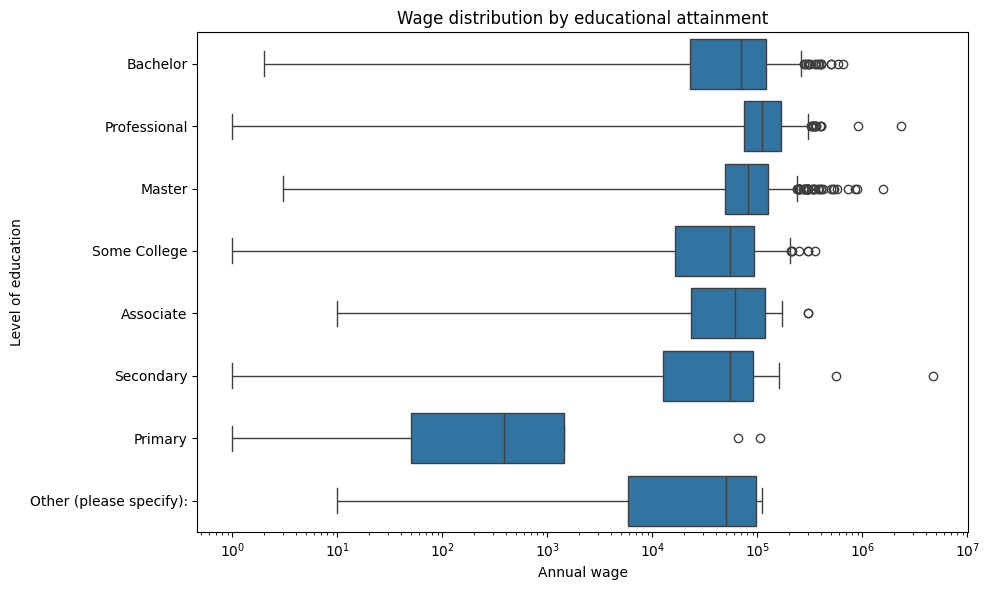

In [10]:
# H2: Boxplot salario por nivel educativo

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_data, x=salary_col, y="EdLevel")
plt.title("Wage distribution by educational attainment")
plt.xlabel("Annual wage")
plt.ylabel("Level of education")
plt.xscale("log")
plt.tight_layout()
plt.show()

### Conclusión H2.1.

Los resultados muestran una asociación positiva entre el nivel educativo y la empleabilidad. Los grupos con mayor cualificación académica presentan los porcentajes más altos de personas empleadas: máster con un 87,55%, grado universitario con un 85,38% y título profesional o doctorado con un 85,09%.

En cambio, los niveles educativos más bajos o menos definidos presentan porcentajes de empleo inferiores, como educación secundaria con un 67,39%, primaria con un 44,44% y la categoría `Other` con un 53,85%. Esto sugiere que una mayor cualificación académica está relacionada con mejores indicadores de empleabilidad dentro de la muestra.

Respecto al salario, también se observa una relación parcial. Los perfiles con `Professional degree` presentan la mayor mediana salarial, seguidos por máster y grado universitario. No obstante, algunas categorías tienen pocos registros o valores extremos que distorsionan la media, por lo que la mediana es una medida más fiable para la comparación.

En conjunto, la hipótesis H2 se acepta parcialmente: una mayor cualificación académica parece asociarse con mayor empleabilidad y mejores salarios, aunque existen diferencias muestrales y outliers que deben considerarse.

H3.1.


In [11]:
# H3: Correlación entre experiencia y salario

df_data[["WorkExp", "YearsCode", salary_col]].corr().round(3)

,WorkExp,YearsCode,ConvertedCompYearly
WorkExp,1.000,0.778,0.138
YearsCode,0.778,1.000,0.172
ConvertedCompYearly,0.138,0.172,1.000


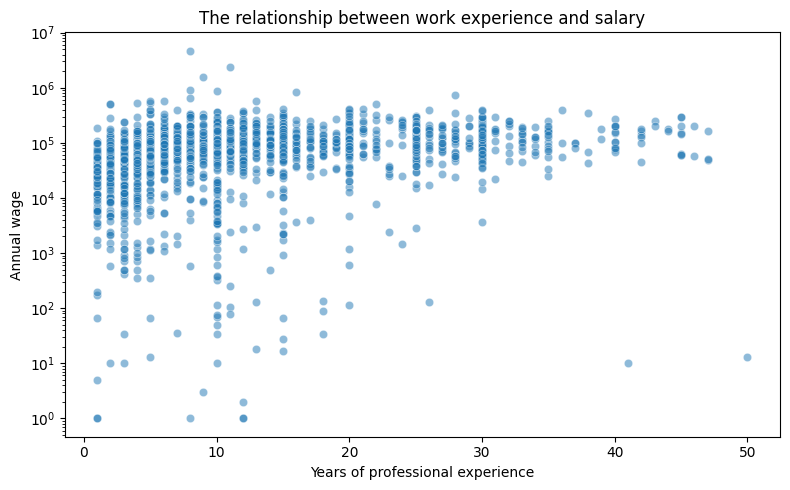

In [12]:
# H3: Relación entre experiencia laboral y salario

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_data, x="WorkExp", y=salary_col, alpha=0.5)
plt.title("The relationship between work experience and salary")
plt.xlabel("Years of professional experience")
plt.ylabel("Annual wage")
plt.yscale("log")
plt.tight_layout()
plt.show()

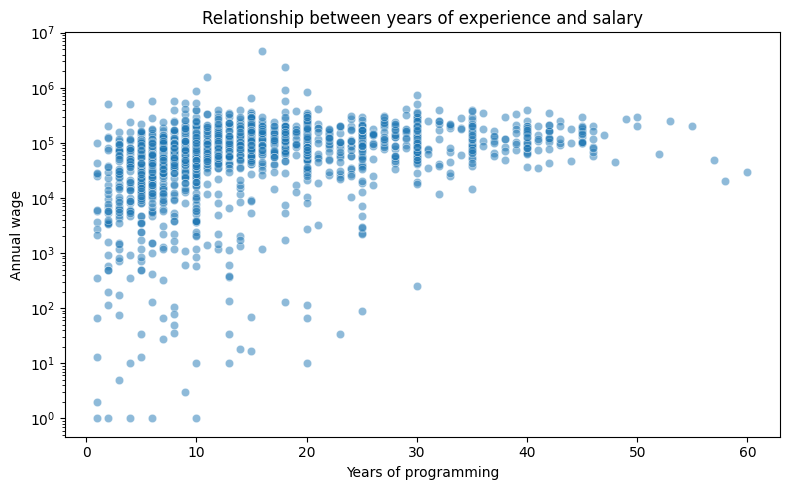

In [13]:
# H3: Relación entre años programando y salario

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_data, x="YearsCode", y=salary_col, alpha=0.5)
plt.title("Relationship between years of experience and salary")
plt.xlabel("Years of programming")
plt.ylabel("Annual wage")
plt.yscale("log")
plt.tight_layout()
plt.show()

In [14]:
# H3: Crear rangos de experiencia laboral

df_data["WorkExp_group"] = pd.cut(
    df_data["WorkExp"],
    bins=[0, 5, 10, 20, 35, 60],
    labels=["0-5", "6-10", "11-20", "21-35", "36+"]
)

salario_experiencia = df_data.groupby("WorkExp_group", observed=True)[salary_col].agg(
    ["count", "mean", "median"]
).round(2)

salario_experiencia

,count,mean,median
WorkExp_group,,,
0-5,514,60748.02,46576.0
6-10,465,112515.59,84568.0
11-20,442,115745.54,94500.0
21-35,272,133252.32,119247.5
36+,48,138181.23,125009.5


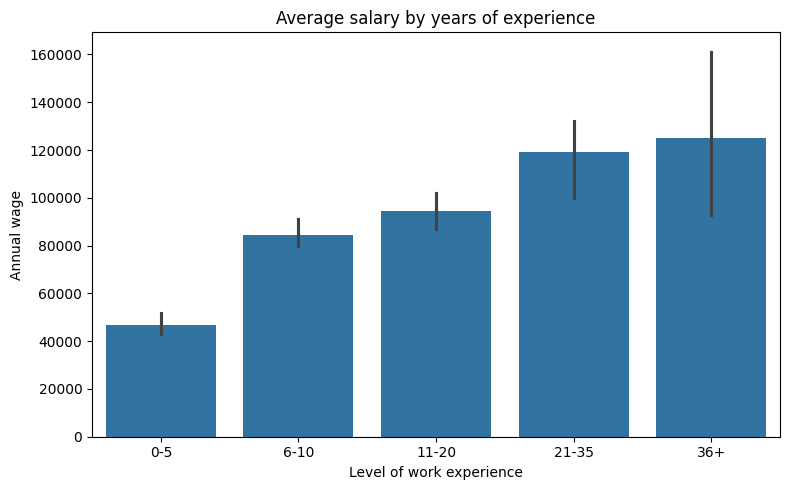

In [15]:
# H3: Mediana salarial por rango de experiencia

plt.figure(figsize=(8, 5))
sns.barplot(data=df_data, x="WorkExp_group", y=salary_col, estimator="median")
plt.title("Average salary by years of experience")
plt.xlabel("Level of work experience")
plt.ylabel("Annual wage")
plt.tight_layout()
plt.show()

### Conclusión H3.1.

Los resultados muestran una relación positiva entre la experiencia y el salario, aunque la correlación lineal es débil. La correlación entre `WorkExp` y `ConvertedCompYearly` es de 0,138, mientras que entre `YearsCode` y `ConvertedCompYearly` es de 0,172. Esto indica que la experiencia se asocia con salarios más altos, pero no explica por sí sola la variabilidad salarial.

Al agrupar la experiencia laboral por rangos, la tendencia resulta más clara. La mediana salarial aumenta desde 46.496 en el grupo de 0-5 años hasta 125.009,5 en el grupo de más de 36 años de experiencia. El salto más importante se observa entre los grupos de 0-5 y 6-10 años.

Los gráficos de dispersión muestran una elevada variabilidad salarial dentro de cada nivel de experiencia, lo que sugiere que otros factores, como país, industria, nivel educativo o tipo de puesto, también influyen en el salario.

En conjunto, la hipótesis H3 se acepta parcialmente: una mayor experiencia está asociada con salarios más altos, especialmente al analizar grupos de experiencia, aunque la relación individual no es fuerte.

H4

In [16]:
# H4: Filtrar empleados y autónomos

df_employment_salary = df_data[
    df_data["Employment"].isin([
        "Employed",
        "Freelancer"
    ])
].copy()

In [17]:
# H4: Comparación salarial por tipo de empleo

salario_tipo_empleo = df_employment_salary.groupby("Employment")[salary_col].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

salario_tipo_empleo

,count,mean,median,min,max
Employment,,,,,
Employed,1468,102366.07,81210.0,1.0,2346000.0
Freelancer,193,117258.80,76520.0,1.0,4706124.0


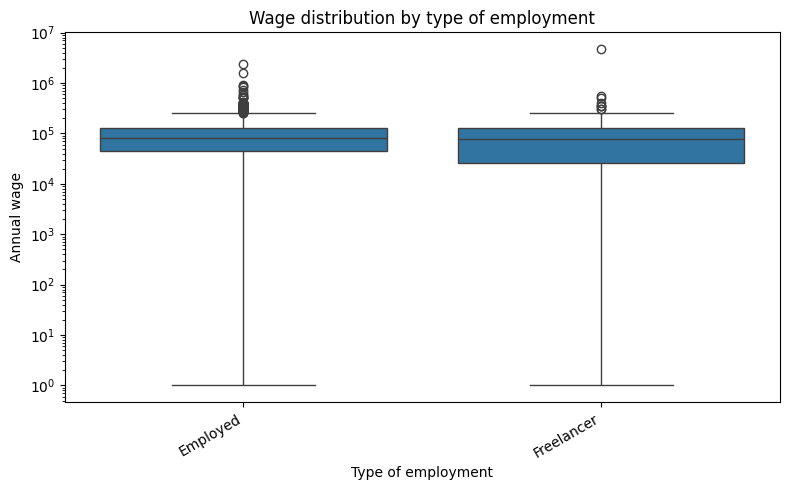

In [18]:
# H4: Boxplot salario según tipo de empleo

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_employment_salary, x="Employment", y=salary_col)
plt.title("Wage distribution by type of employment")
plt.xlabel("Type of employment")
plt.ylabel("Annual wage")
plt.yscale("log")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Conclusión H4

Los resultados no permiten confirmar claramente que los autónomos cobren más que los trabajadores por cuenta ajena. Aunque la media salarial de los autónomos o freelancers es superior a la de los empleados, con 117.258,8 frente a 102.326,4, la mediana salarial es ligeramente inferior en el grupo de autónomos: 76.520 frente a 81.210 en empleados.

Dado que la variable salarial presenta valores extremos, la mediana resulta más representativa que la media. El grupo de autónomos contiene un valor máximo muy elevado, de 4.706.124, que probablemente incrementa la media y distorsiona la comparación.

Además, existe una diferencia importante en el tamaño de los grupos, con 1469 empleados frente a 193 autónomos. Por tanto, la hipótesis H4 se rechaza parcialmente: los autónomos presentan una media más alta, pero no una mediana superior, por lo que no puede afirmarse de forma robusta que cobren más.

H5

In [19]:
# H5: AISelect y salario

salario_ai = df_data.groupby("AISelect")[salary_col].agg(
    ["count", "mean", "median"]
).round(2)

salario_ai

,count,mean,median
AISelect,,,
No,308,103116.89,85925.5
Yes,1360,103543.20,79001.0


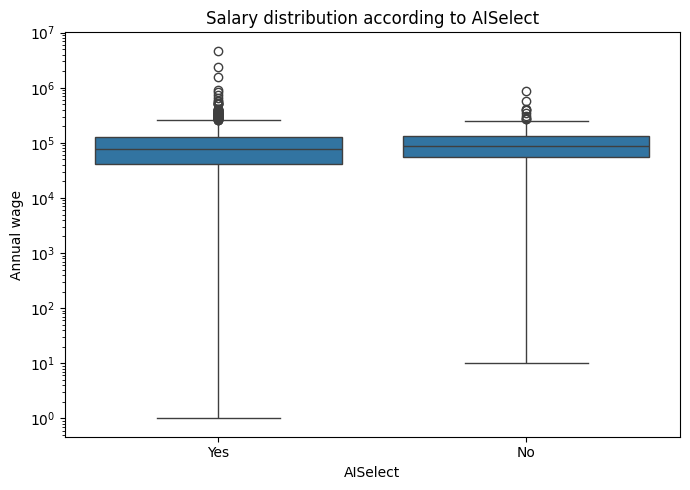

In [20]:
# H5: Boxplot salario según AISelect

plt.figure(figsize=(7, 5))
sns.boxplot(data=df_data, x="AISelect", y=salary_col)
plt.title("Salary distribution according to AISelect")
plt.xlabel("AISelect")
plt.ylabel("Annual wage")
plt.yscale("log")
plt.tight_layout()
plt.show()

In [21]:
# H5: AISelect y satisfacción laboral

jobsat_ai = df_data.groupby("AISelect")["JobSat"].agg(
    ["count", "mean", "median"]
).round(2)

jobsat_ai

,count,mean,median
AISelect,,,
No,176,7.20,8.0
Yes,984,7.24,8.0


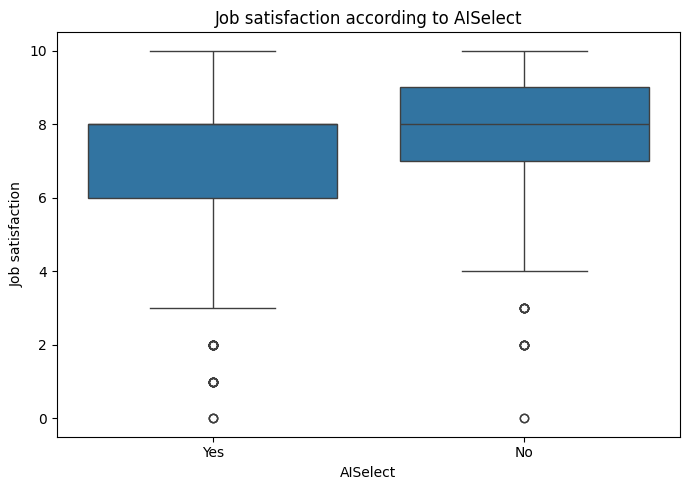

In [22]:
# H5: Boxplot satisfacción laboral según AISelect

plt.figure(figsize=(7, 5))
sns.boxplot(data=df_data, x="AISelect", y="JobSat")
plt.title("Job satisfaction according to AISelect")
plt.xlabel("AISelect")
plt.ylabel("Job satisfaction")
plt.tight_layout()
plt.show()

### Conclusión H5

Los resultados no muestran una ventaja clara asociada a `AISelect` en términos salariales o de satisfacción laboral. La media salarial es prácticamente igual entre quienes responden `Yes` y quienes responden `No`, con 103.499,51 frente a 103.116,89. Además, la mediana salarial es mayor en el grupo `No`, con 85.925,5 frente a 78.959 en el grupo `Yes`.

En cuanto a la satisfacción laboral, las diferencias también son mínimas. Ambos grupos presentan una mediana de 8 y medias muy similares, 7,23 para `Yes` y 7,20 para `No`.

Por tanto, con las variables disponibles, la hipótesis H5 no se confirma. No se observa una relación clara entre responder afirmativamente en `AISelect` y obtener mejores indicadores salariales o de satisfacción laboral. Además, debe tenerse en cuenta que `AISelect` no necesariamente mide trabajar directamente con IA, por lo que la interpretación debe hacerse con cautela.

H6

In [23]:
# H6: Salario por industria

salario_industria = df_data.groupby("Industry")[salary_col].agg(
    ["count", "mean", "median"]
).sort_values("median", ascending=False).round(2)

salario_industria

,count,mean,median
Industry,,,
Insurance,37,126766.03,105060.0
Healthcare,125,125620.80,100000.0
Computer Systems Design and Services,50,127915.48,97559.5
Energy,73,112127.14,95000.0
Government,114,97451.18,87005.5
Fintech,75,96505.55,84568.0
"Internet, Telecomm or Information Services",94,121571.07,82128.0
Other:,198,90672.31,82027.5
Media & Advertising Services,57,94812.70,81210.0


In [24]:
# H6: Ranking de industrias por mediana salarial
# Se filtran industrias con al menos 30 registros para evitar conclusiones con muestras muy pequeñas

top_industrias = salario_industria[salario_industria["count"] >= 30].sort_values(
    "median",
    ascending=False
)

top_industrias

,count,mean,median
Industry,,,
Insurance,37,126766.03,105060.0
Healthcare,125,125620.80,100000.0
Computer Systems Design and Services,50,127915.48,97559.5
Energy,73,112127.14,95000.0
Government,114,97451.18,87005.5
Fintech,75,96505.55,84568.0
"Internet, Telecomm or Information Services",94,121571.07,82128.0
Other:,198,90672.31,82027.5
Media & Advertising Services,57,94812.70,81210.0


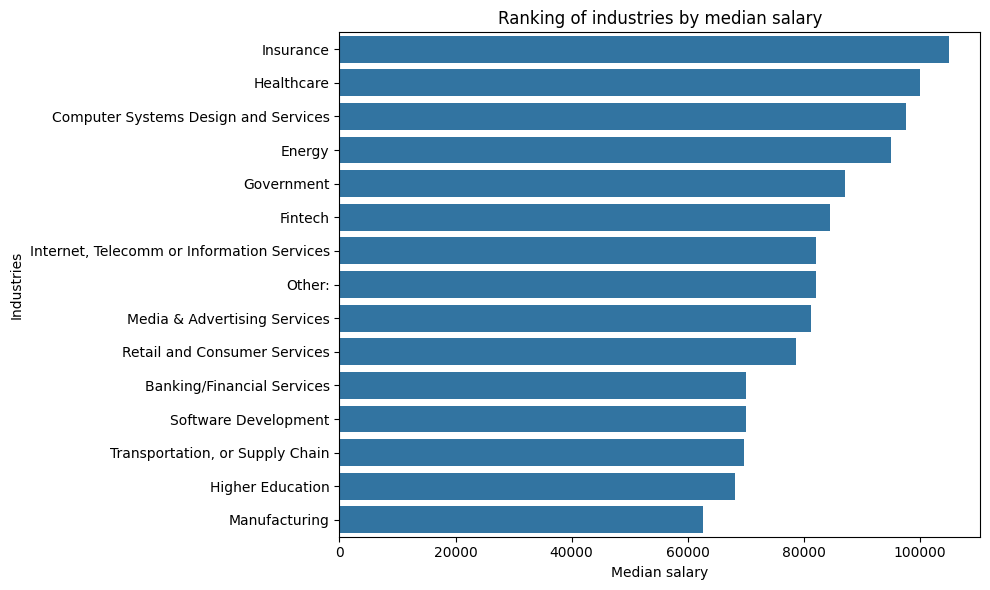

In [25]:
# H6: Gráfico ranking de industrias

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_industrias.reset_index(),
    x="median",
    y="Industry"
)
plt.title("Ranking of industries by median salary")
plt.xlabel("Median salary")
plt.ylabel("Industries")
plt.tight_layout()
plt.show()

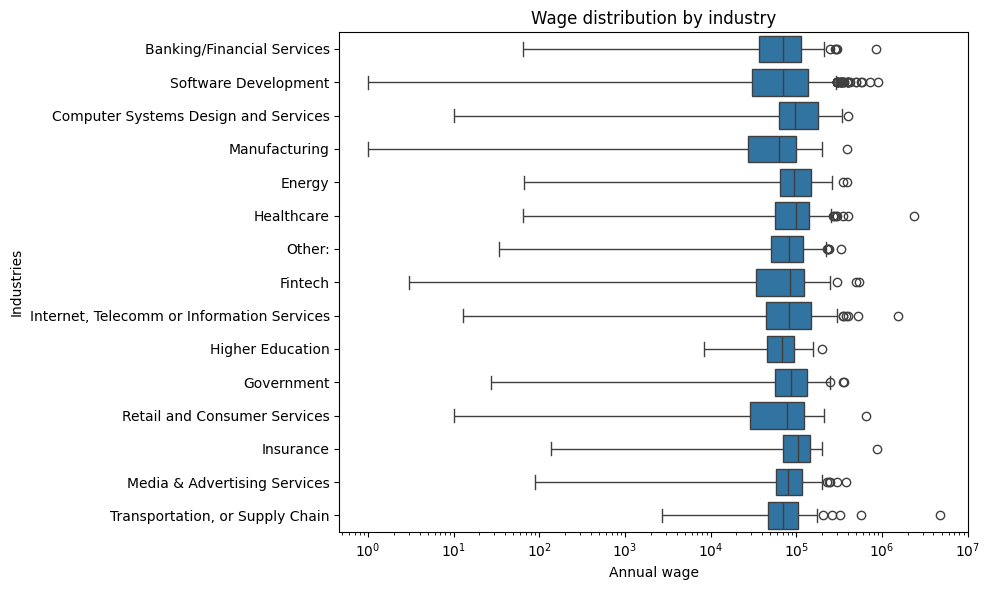

In [26]:
# H6: Boxplot salario por industria

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_data, x=salary_col, y="Industry")
plt.title("Wage distribution by industry")
plt.xlabel("Annual wage")
plt.ylabel("Industries")
plt.xscale("log")
plt.tight_layout()
plt.show()

### Conclusión H6

Los resultados muestran diferencias salariales relevantes entre industrias, por lo que la hipótesis H6 se acepta. La mediana salarial varía de forma notable según el sector, desde los 62.648 en `Manufacturing` hasta los 105.060 en `Insurance`.

Las industrias con mayores medianas salariales son `Insurance`, `Healthcare`, `Computer Systems Design and Services`, `Energy` y `Government`. En cambio, sectores como `Manufacturing`, `Higher Education`, `Transportation, or Supply Chain`, `Banking/Financial Services` y `Software Development` presentan medianas más bajas.

También se observa que algunas industrias tienen medias muy superiores a sus medianas, como `Transportation, or Supply Chain`, lo que indica la presencia de valores salariales extremos que elevan la media. Por este motivo, la mediana resulta más adecuada para comparar los salarios entre sectores.

En conjunto, el tipo de industria parece influir en el salario anual, aunque las diferencias deben interpretarse considerando la dispersión interna y los valores atípicos presentes en cada sector.

### Conclusión final del análisis bivariante

El análisis bivariante permite observar que varias de las hipótesis planteadas encuentran apoyo parcial o claro en los datos. En primer lugar, se aprecia una relación positiva entre edad y salario: la mediana salarial aumenta desde los grupos más jóvenes hasta los perfiles de mayor edad, aunque la relación no es completamente lineal y algunos grupos tienen pocos registros.

También se observa una asociación entre nivel educativo y empleabilidad. Los niveles de máster, grado universitario y título profesional presentan los porcentajes más altos de personas empleadas, además de mejores medianas salariales. Sin embargo, algunas categorías educativas tienen tamaños muestrales reducidos o valores extremos, por lo que las conclusiones deben interpretarse con cautela.

Respecto a la experiencia, existe una tendencia positiva entre años de experiencia y salario. Aunque las correlaciones lineales son débiles, el análisis por rangos muestra que la mediana salarial aumenta progresivamente desde los perfiles con menos experiencia hasta los más senior. Esto sugiere que la experiencia influye en el salario, pero no es el único factor explicativo.

La hipótesis de que los autónomos cobran más que los empleados no se confirma claramente. Los autónomos presentan una media salarial superior, pero su mediana es menor que la de los empleados, lo que indica que la media está influida por valores extremos. Por tanto, no puede afirmarse de forma sólida que los trabajadores autónomos cobren más.

En relación con `AISelect`, no se observan diferencias claras en salario ni satisfacción laboral entre quienes responden `Yes` y quienes responden `No`. Las medias son muy similares y las medianas no muestran ventaja para el grupo `Yes`, por lo que esta hipótesis no queda respaldada con las variables disponibles.

Por último, la industria sí parece influir en el salario. Existen diferencias importantes entre sectores, con mayores medianas salariales en industrias como `Insurance`, `Healthcare`, `Computer Systems Design and Services` y `Energy`. Además, se detectan sectores con medias elevadas debido a valores atípicos, por lo que la mediana resulta más fiable para comparar.

En conjunto, el análisis bivariante muestra que el salario está relacionado con múltiples factores, especialmente edad, experiencia, nivel educativo e industria. No obstante, la presencia de outliers salariales y diferencias de tamaño entre grupos obliga a interpretar los resultados con prudencia.